In [1]:
# Imports
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import json

In [2]:
current_directory = Path.cwd().parent
discharge_directory = Path.joinpath(current_directory, "Data Start Point")

compiled_file_name = Path.joinpath(discharge_directory, "compiled_output.csv")
output_file_name = Path.joinpath(discharge_directory, "final_cleaned_compiled.csv")
points_of_interest_file_name = Path.joinpath(discharge_directory, "points_of_interest.json")

def create_csv_output_file(override=False, csv_data=None):
    if override and Path.exists(output_file_name):
        Path.unlink(output_file_name)
    
    if csv_data is not None:
        csv_data.to_csv(output_file_name, mode='a', header=not Path.exists(output_file_name), index=False)

In [3]:
combined_df = pd.read_csv(compiled_file_name)
print(combined_df.shape)
print(combined_df.head())

(623042, 8)
   Translated Time  Translated Time (minutes)  \
0             1000                   0.016667   
1             1032                   0.017200   
2             1064                   0.017733   
3             1095                   0.018250   
4             1126                   0.018767   

   ADS Reading 1 (Smoothed and Offset)  Calibrated Current 1  \
0                             2.863429              0.008564   
1                            -1.136571             -0.003399   
2                             1.863429              0.005573   
3                             1.863429              0.005573   
4                            -3.136571             -0.009381   

   ADS Reading 2 (Smoothed and Offset)  Calibrated Current 2  \
0                             4.816303              0.014406   
1                             4.816303              0.014406   
2                             4.816303              0.014406   
3                             4.816303              

In [37]:
CIRCUIT_CLOSE_VOLTAGE_DROP_THRESHOLD = 0.3
prev_found_time = -999

# Tuple of time (min) and voltage
last_stable_voltages_before_close = {"index": [], "time": [], "voltage": []}
for index in range(20, len(combined_df) - 10000):
    if index % 10000 == 0:
        print(f"Processing index {index}/{len(combined_df)}", end="\r")   
    # Voltage drop + time gap > 1 min + voltage drop > threshold
    if combined_df["Translated Time (minutes)"].iloc[index] - prev_found_time > 1:
        curr = combined_df['Calibrated Voltage'].iloc[index]    # Current point
        following = combined_df['Calibrated Voltage'].iloc[index:index+500].mean() # Avg of next few point to confirm it is the edge
        next = combined_df['Calibrated Voltage'].iloc[index+9000:index+10000].max() # Ensure that drop is not due to noise
        
        if curr - following > 0.01 and curr > next + CIRCUIT_CLOSE_VOLTAGE_DROP_THRESHOLD:
            print(f"Found potential circuit close at index {index} with voltage drop from {curr:.2f} V to {next:.2f} V at time {combined_df['Translated Time (minutes)'].iloc[index]:.2f} min.")
            # Take a few step back to get last stable voltage before circuit close
            last_stable_voltages_before_close['index'].append(index)
            last_stable_voltages_before_close['time'].append(combined_df["Translated Time (minutes)"].iloc[index-20:index].mean())
            last_stable_voltages_before_close['voltage'].append(combined_df['Calibrated Voltage'].iloc[index-20:index].mean())
            prev_found_time = combined_df["Translated Time (minutes)"].iloc[index]
    
print("Found", len(last_stable_voltages_before_close['time']), "points\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t")
is_close_filtered = False

Found potential circuit close at index 20 with voltage drop from 58.20 V to 55.62 V at time 0.04 min.
Found potential circuit close at index 1262 with voltage drop from 56.16 V to 55.55 V at time 1.04 min.
Found potential circuit close at index 2376 with voltage drop from 56.00 V to 55.49 V at time 2.04 min.
Found potential circuit close at index 32019 with voltage drop from 57.05 V to 54.86 V at time 27.47 min.
Found potential circuit close at index 33238 with voltage drop from 55.36 V to 54.80 V at time 28.47 min.
Found potential circuit close at index 34522 with voltage drop from 55.18 V to 54.74 V at time 29.47 min.
Found potential circuit close at index 35942 with voltage drop from 55.09 V to 54.67 V at time 30.47 min.
Found potential circuit close at index 94585 with voltage drop from 56.33 V to 53.97 V at time 74.67 min.
Found potential circuit close at index 95898 with voltage drop from 54.52 V to 53.91 V at time 75.67 min.
Found potential circuit close at index 97226 with volt

In [39]:
print(last_stable_voltages_before_close['time'])
print(last_stable_voltages_before_close['voltage'])
to_drop = []
for index in range(1, len(last_stable_voltages_before_close['time'])):
    if last_stable_voltages_before_close['voltage'][index] > last_stable_voltages_before_close['voltage'][index-1]:
        curr_voltage = last_stable_voltages_before_close['voltage'][index]
        for i in range(index):
            if last_stable_voltages_before_close['voltage'][i] < curr_voltage:
                to_drop.append(i)

print("Dropping indices", to_drop)
last_stable_voltages_before_close['index'] = [index for i, index in enumerate(last_stable_voltages_before_close['index']) if i not in to_drop]
last_stable_voltages_before_close['time'] = [time for i, time in enumerate(last_stable_voltages_before_close['time']) if i not in to_drop]
last_stable_voltages_before_close['voltage'] = [voltage for i, voltage in enumerate(last_stable_voltages_before_close['voltage']) if i not in to_drop]
print("After dropping, found", len(last_stable_voltages_before_close['time']), "points")

[np.float64(0.021642499999999967), np.float64(1.0278708333333335), np.float64(2.031180833333333), np.float64(27.460005000000002), np.float64(28.460117500000003), np.float64(29.45824), np.float64(30.45826833333333), np.float64(74.65789333333333), np.float64(75.66009083333334), np.float64(76.65868666666667), np.float64(77.65999166666668), np.float64(78.66051083333333), np.float64(79.66286333333333), np.float64(120.16813833333333), np.float64(121.16577499999998), np.float64(162.80409583333332), np.float64(163.8031866666667), np.float64(164.9236541666667), np.float64(194.19948250000002), np.float64(220.98811499999996), np.float64(221.99262916666666), np.float64(222.99086499999999), np.float64(253.08190833333333), np.float64(254.08248999999995), np.float64(297.7209833333333), np.float64(298.722945), np.float64(336.9117625), np.float64(337.91102083333334), np.float64(381.5407566666667), np.float64(382.54138583333327), np.float64(383.54216499999995), np.float64(426.0909141666667), np.float64(

In [51]:
CIRCUIT_OPEN_VOLTAGE_JUMP_THRESHOLD = 0.5
prev_found_time = -999
# Tuple of time (min) and voltage
last_stable_voltages_before_open = {"index": [], "time": [], "voltage": []}

for index in range(20, len(combined_df)-500): 
    if index % 1000 == 0:
        print(f"Processing index {index}/{len(combined_df)}", end="\r")   
    # Voltage drop + time gap > 1 min + voltage drop > threshold
    if combined_df["Translated Time (minutes)"].iloc[index] - prev_found_time > 1:
        curr = combined_df['Calibrated Voltage'].iloc[index]
        next = combined_df['Calibrated Voltage'].iloc[index+9000:index+10000].min()
        following = combined_df['Calibrated Voltage'].iloc[index+1:index+500].mean() # Avg of next few point to confirm it is the edge
        
        if following - curr > 0.1 and next - curr > CIRCUIT_OPEN_VOLTAGE_JUMP_THRESHOLD:
            print(f"Found potential circuit open at index {index} with voltage jump from {curr:.2f} V to {next:.2f} V at time {combined_df['Translated Time (minutes)'].iloc[index]:.2f} min.")
            # Take a few step back to get last stable voltage before circuit open
            last_stable_voltages_before_open['index'].append(index)
            last_stable_voltages_before_open['time'].append(combined_df["Translated Time (minutes)"].iloc[index-20:index].mean())
            last_stable_voltages_before_open['voltage'].append(combined_df['Calibrated Voltage'].iloc[index-20:index].mean())
            prev_found_time = combined_df["Translated Time (minutes)"].iloc[index]
    
print("Found", len(last_stable_voltages_before_open['time']), "points")
is_open_filtered = False

Found potential circuit open at index 12852 with voltage jump from 55.42 V to 57.02 V at time 10.52 min.
Found potential circuit open at index 46250 with voltage jump from 54.60 V to 56.24 V at time 38.43 min.
Found potential circuit open at index 111915 with voltage jump from 53.59 V to 55.27 V at time 87.31 min.
Found potential circuit open at index 163157 with voltage jump from 52.41 V to 53.88 V at time 125.35 min.
Found potential circuit open at index 168523 with voltage jump from 52.27 V to 53.96 V at time 131.23 min.
Found potential circuit open at index 220255 with voltage jump from 51.49 V to 53.08 V at time 174.16 min.
Found potential circuit open at index 256414 with voltage jump from 50.84 V to 52.34 V at time 204.22 min.
Found potential circuit open at index 294075 with voltage jump from 50.19 V to 51.75 V at time 232.11 min.
Found potential circuit open at index 334847 with voltage jump from 49.63 V to 51.22 V at time 265.83 min.
Found potential circuit open at index 3913

In [7]:
bak_last_stable_voltages_before_open = last_stable_voltages_before_open.copy()
bak_last_stable_voltages_before_close = last_stable_voltages_before_close.copy()

In [77]:
# Drop points from visual inspection of before circuit close
list_to_drop = [7,8,9,10,11,12,13,14]
if not is_close_filtered:
    list_to_drop.sort(reverse=True)
    for i in list_to_drop:
        del last_stable_voltages_before_close['index'][i]
        del last_stable_voltages_before_close['time'][i]
        del last_stable_voltages_before_close['voltage'][i]
    is_close_filtered = True

In [53]:
# Drop points from visual inspection of before circuit open
list_to_drop = [3]
if not is_open_filtered:
    list_to_drop.sort(reverse=True)
    for i in list_to_drop:
        del last_stable_voltages_before_open['index'][i]
        del last_stable_voltages_before_open['time'][i]
        del last_stable_voltages_before_open['voltage'][i]
    is_open_filtered = True

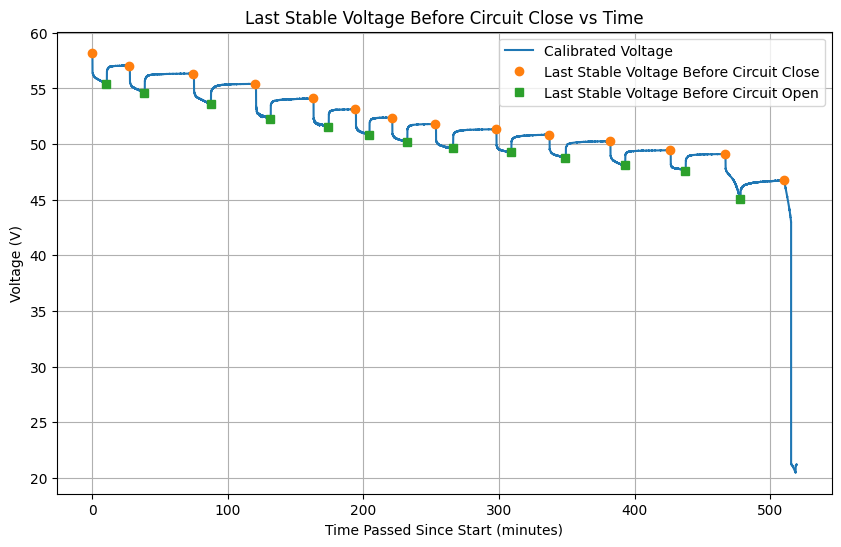

In [54]:
plt.figure(figsize=(10, 6))
plt.plot(combined_df['Translated Time (minutes)'], combined_df['Calibrated Voltage'], label='Calibrated Voltage')
plt.plot(last_stable_voltages_before_close['time'], last_stable_voltages_before_close['voltage'], 'o', label='Last Stable Voltage Before Circuit Close')
plt.plot(last_stable_voltages_before_open['time'], last_stable_voltages_before_open['voltage'], 's', label='Last Stable Voltage Before Circuit Open')
plt.xlabel('Time Passed Since Start (minutes)')
plt.ylabel('Voltage (V)')
plt.title('Last Stable Voltage Before Circuit Close vs Time')
plt.legend()
plt.grid()
plt.show()

In [33]:
combined_df.loc[612401:613372, "Calibrated Voltage"] = 46.8


In [69]:
is_close_filtered = False
is_open_filtered = False

In [ ]:
is_close_filtered = True
is_open_filtered = True

In [79]:
print(last_stable_voltages_before_close)
print(last_stable_voltages_before_open)

{'index': [1492630, 2671045, 4239708, 5523407, 6945422, 8190944, 9440165], 'time': [np.float64(24.10656765166666), np.float64(43.66643954999999), np.float64(68.95378443000001), np.float64(89.75069793250005), np.float64(112.76274617000001), np.float64(132.93641707333336), np.float64(153.0244092233334)], 'voltage': [np.float64(52.82729045548181), np.float64(52.635896910048075), np.float64(52.32712657358663), np.float64(52.22109370565346), np.float64(52.188561959258415), np.float64(51.905010757610434), np.float64(51.23853183794919)]}
{'index': [784146, 2092393, 3595802, 4875703, 6146751, 7556718, 8810603], 'time': [np.float64(12.60611630083333), np.float64(34.32035291666666), np.float64(58.524366486666665), np.float64(79.33039983083337), np.float64(99.81197282333336), np.float64(122.70627217333337), np.float64(142.9380094)], 'voltage': [np.float64(50.26886079194324), np.float64(50.57847489127948), np.float64(17.035338063630128), np.float64(50.39856589608606), np.float64(50.209703639276725

In [11]:
print(combined_df['Calibrated Voltage'].iloc[1480000])

IndexError: single positional indexer is out-of-bounds

In [83]:
# replace idx 0 before close 
last_stable_voltages_before_close['index'][0] = 1480000
last_stable_voltages_before_close['time'][0] = combined_df['Translated Time (minutes)'].iloc[last_stable_voltages_before_close['index'][0]]
last_stable_voltages_before_close['voltage'][0] = combined_df['Calibrated Voltage'].iloc[last_stable_voltages_before_close['index'][0]]

In [10]:
idx = 3595802
while combined_df['Calibrated Voltage'].iloc[idx] < 25:
    idx += 1
print('Found', idx, 'with voltage', combined_df['Calibrated Voltage'].iloc[idx], 'at time', combined_df['Translated Time (minutes)'].iloc[idx])

IndexError: single positional indexer is out-of-bounds

In [92]:
# replace idx 0 before open 
last_stable_voltages_before_open['index'][2] = 3596300 
last_stable_voltages_before_open['time'][2] = combined_df['Translated Time (minutes)'].iloc[last_stable_voltages_before_open['index'][2]]
last_stable_voltages_before_open['voltage'][2] = combined_df['Calibrated Voltage'].iloc[last_stable_voltages_before_open['index'][2]]

In [55]:
create_csv_output_file(override=True, csv_data=combined_df)

In [56]:
outpus_json_points = {
    "before_close": {
        "index": last_stable_voltages_before_close['index'],
        "time": last_stable_voltages_before_close['time'],
        "voltage": last_stable_voltages_before_close['voltage']
    },
    "before_open": {
        "index": last_stable_voltages_before_open['index'],
        "time": last_stable_voltages_before_open['time'],
        "voltage": last_stable_voltages_before_open['voltage']
    }
}
print(f"Saved {len(last_stable_voltages_before_close['index'])} points for before close and {len(last_stable_voltages_before_open['time'])} points for before open to {points_of_interest_file_name}.")
json.dump(outpus_json_points, open(points_of_interest_file_name, 'w'), indent=4)

Saved 14 points for before close and 13 points for before open to c:\Users\Kor\Documents\GitHub\Proa-II-Electrical-Setup\Calibration Data 2\Data\Data Start Point\points_of_interest.json.
